# Load Data

In [1]:
# TODO change config!!
from configs.config_s import config  # Microflora Danica
# from configs.config_butterfly import config  # UK Butterfly

In [2]:
import torch
import pyro
import pyro.distributions as dist
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import tqdm

import gpytorch

import wandb
import sys
import os

from EcoGP.model import EcoGP
# from EcoGP.model_old import MicroGP as EcoGP; print("USING OLD MODEL!")

from torch.utils.data import DataLoader, random_split
from EcoGP.DataSampler import DataSampler
from EcoGP.DataLoad import DataLoad
from EcoGP.BetaTraceELBO import BetaTraceELBO

from sklearn import metrics

from EcoGP.misc.metrics import precision_at_k

In [3]:
# ARGUMENTS
environment = config["additive"]["environment"]
spatial = config["additive"]["spatial"]
traits = config["additive"]["traits"]

x_path = config["data"]["X_path"]#.replace("clean", "full")
y_path = config["data"]["Y_path"]#.replace("clean", "full")
coords_path = config["data"]["coords_path"]#.replace("clean", "full")
traits_path = config["data"]["traits_path"]
total_counts_path = config["data"]["total_counts_path"]
#hierarchy_path = config["data"]["hierarchy_path"]

n_latents_env = config["environmental"]["n_latents"]
n_latents_spatial = config["spatial"]["n_latents"]
n_iter = config["general"]["n_iter"]
n_particles = config["general"]["n_particles"]
device = config["general"]["device"]
lr = config["general"]["lr"]
batch_size = config["general"]["batch_size"]
split_pct = config["general"]["split_pct"]
n_inducing_points_env = config["environmental"]["n_inducing_points"]
n_inducing_points_spatial = config["spatial"]["n_inducing_points"]

verbose = config["general"]["verbose"]
presence_absence = config["data"]["presence_absence"]
normalize_X = config["data"]["normalize_X"]
likelihood = config["general"]["likelihood"]
seed = config["general"]["seed"]

# prevalence_threshold = config["data"]["prevalence_threshold"]

save_model_path = config["general"]["save_model_path"]
# STOP ARGUMENTS

torch.manual_seed(seed)

data = DataLoad(
    Y_path=y_path,
    X_path=x_path,
    coords_path=coords_path,
    traits_path=traits_path,
    device=device,
    normalize_X=normalize_X,
    total_counts_path=total_counts_path,
    presence_absence_Y=presence_absence,
    verbose=verbose
)

dataset = DataSampler(data)

if spatial:
    train_indices, test_indices, validation_indices = random_split(torch.arange(dataset.unique_coords.shape[0]),
                                                                   split_pct,
                                                                   generator=torch.Generator().manual_seed(seed))

    # Getting the spatial locations split into separate sets
    train_indices = dataset.coords_inverse_indicies[
        torch.isin(dataset.coords_inverse_indicies, torch.tensor(train_indices.indices))]
    test_indices = dataset.coords_inverse_indicies[
        torch.isin(dataset.coords_inverse_indicies, torch.tensor(test_indices.indices))]
    validation_indices = dataset.coords_inverse_indicies[
        torch.isin(dataset.coords_inverse_indicies, torch.tensor(validation_indices.indices))]

    train_dataset = torch.utils.data.Subset(dataset, train_indices)
    test_dataset = torch.utils.data.Subset(dataset, test_indices)
    validation_dataset = torch.utils.data.Subset(dataset, validation_indices)
else:
    train_dataset, test_dataset, validation_dataset = random_split(dataset, split_pct,
                                                                   generator=torch.Generator().manual_seed(seed))

# Make sure at least 1 species obserservations are present all splits
# Can't make predictions for a species not present in training
keep_y = (dataset.Y[train_dataset.indices].sum(dim=0) >= split_pct[0] * 10) & (
            dataset.Y[test_dataset.indices].sum(dim=0) >= split_pct[1] * 10) & (
            dataset.Y[validation_dataset.indices].sum(dim=0) >= split_pct[2] * 10)
dataset.Y = dataset.Y[:, keep_y]
dataset.taxon_names = dataset.taxon_names[keep_y]
dataset.n_species = dataset.Y.shape[1]
if traits_path:
    dataset.traits = dataset.traits[keep_y, :]
if verbose:
    print(f"Keeping {keep_y.sum().item()} taxons with at least {split_pct} * 10 "
          f"observations per split, respectively.")

Load X: 2337 sample sites and 103 environmental variables
Load Y: 2337 sample sites and 15013 taxons
Standard Normalizing Coordinates
len(self.unique_coords)=2335
Keeping 7729 taxons with at least [0.7, 0.2, 0.1] * 10 observations per split, respectively.


In [4]:
train_dataloader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

coords = dataset.coords[train_dataset.indices]
Y = dataset.Y[train_dataset.indices]
# coords = dataset.X[train_dataset.indices]

n_S = coords.shape[1]; print(n_S)

I, J = Y.shape

num_latents = 5
num_tasks = J

2


In [5]:
from sklearn import metrics

def calculate_metrics(y_true, y_pred):
    auc_per_species = [
        metrics.roc_auc_score(y_true[:, i], y_pred[:, i]) if not all(
            y_true[:, i] == 0) else float("nan") for i in
        range(y_true.shape[1])
    ]
    auc = torch.tensor(auc_per_species)
    auc = (auc[~torch.isnan(auc)]).mean().item()
    return auc

# GPyTorch

In [6]:

class MultitaskGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, num_latents, num_tasks):
        # Let's use a different set of inducing points for each latent function
        # inducing_points = torch.rand(num_latents, 16, n_S)
        # a = torch.linspace(-1, 2, 4)
        # b = torch.linspace(-1, 2, 4)
        a = torch.linspace(coords[:, 0].min(), coords[:, 0].max(), 4)
        b = torch.linspace(coords[:, 1].min(), coords[:, 1].max(), 4)
        A, B = torch.meshgrid(a, b, indexing="ij")
        inducing_points = torch.stack([A.flatten(), B.flatten()], dim=1).repeat(num_latents, 1, 1)
        
        inducing_points += torch.randn_like(inducing_points) * 0.1

        # We have to mark the CholeskyVariationalDistribution as batch
        # so that we learn a variational distribution for each task
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([num_latents])
        )

        # We have to wrap the VariationalStrategy in a LMCVariationalStrategy
        # so that the output will be a MultitaskMultivariateNormal rather than a batch output
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self, inducing_points, variational_distribution, learn_inducing_locations=True
            ),
            num_tasks=num_tasks,
            num_latents=num_latents,
        )

        super().__init__(variational_strategy)

        # The mean and covariance modules should be marked as batch
        # so we learn a different set of hyperparameters
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.MaternKernel(
            lengthscale_prior=gpytorch.priors.NormalPrior(5, 5),
            batch_shape=torch.Size([num_latents]),
            # ard_num_dims=n_S
        )
        # self.covar_module = gpytorch.kernels.ScaleKernel(
        #     gpytorch.kernels.RBFKernel(
        #         lengthscale_prior=gpytorch.priors.NormalPrior(loc=5, scale=25),
        #         batch_shape=torch.Size([num_latents]),
        #     ),
        #     outputscale_prior=gpytorch.priors.GammaPrior(rate=1, concentration=1),
        #     batch_shape=torch.Size([num_latents])
        # )
        
        self.covar_module.lengthscale = torch.rand(num_latents, 1, 1, dtype=torch.float32) * 0.1
            

    def forward(self, x):
        # The forward function should be written as if we were dealing with each output
        # dimension in batch
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

## Train GPyTorch

In [7]:
pyro.clear_param_store()

model = MultitaskGPModel(num_latents, num_tasks)
likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=num_tasks)
# likelihood = gpytorch.likelihoods.BernoulliLikelihood()
    
    
num_epochs = 200


# model.train()
# likelihood.train()

optimizer = torch.optim.Adam([
    {'params': model.parameters()},
    {'params': likelihood.parameters()},
], lr=0.1)

# Our loss object. We're using the VariationalELBO, which essentially just computes the ELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=I)

points = [model.variational_strategy.base_variational_strategy.inducing_points.clone().detach()]

losses = []
# We use more CG iterations here because the preconditioner introduced in the NeurIPS paper seems to be less
# effective for VI.
epochs_iter = tqdm.notebook.tqdm(range(num_epochs), desc="Epoch")
for i in epochs_iter:
    # Within each iteration, we will go over each minibatch of data
    optimizer.zero_grad()
    output = model(coords)
    loss = -mll(output, Y)
    epochs_iter.set_postfix(loss=loss.item(), lengthscale=str([round(i.item(), 3) for i in model.covar_module.lengthscale.squeeze()]))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    points.append(model.variational_strategy.base_variational_strategy.inducing_points.clone().detach())
    
points = torch.stack(points)

Epoch:   0%|          | 0/200 [00:00<?, ?it/s]

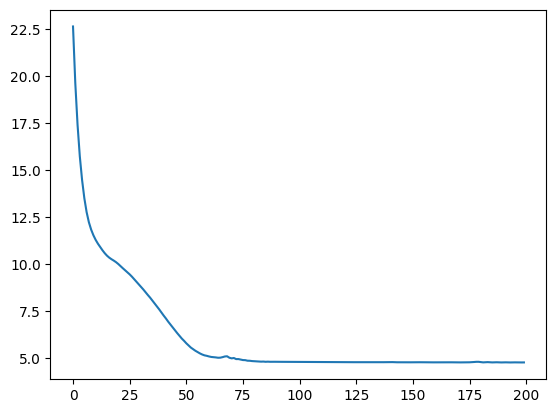

In [8]:
plt.plot(losses)

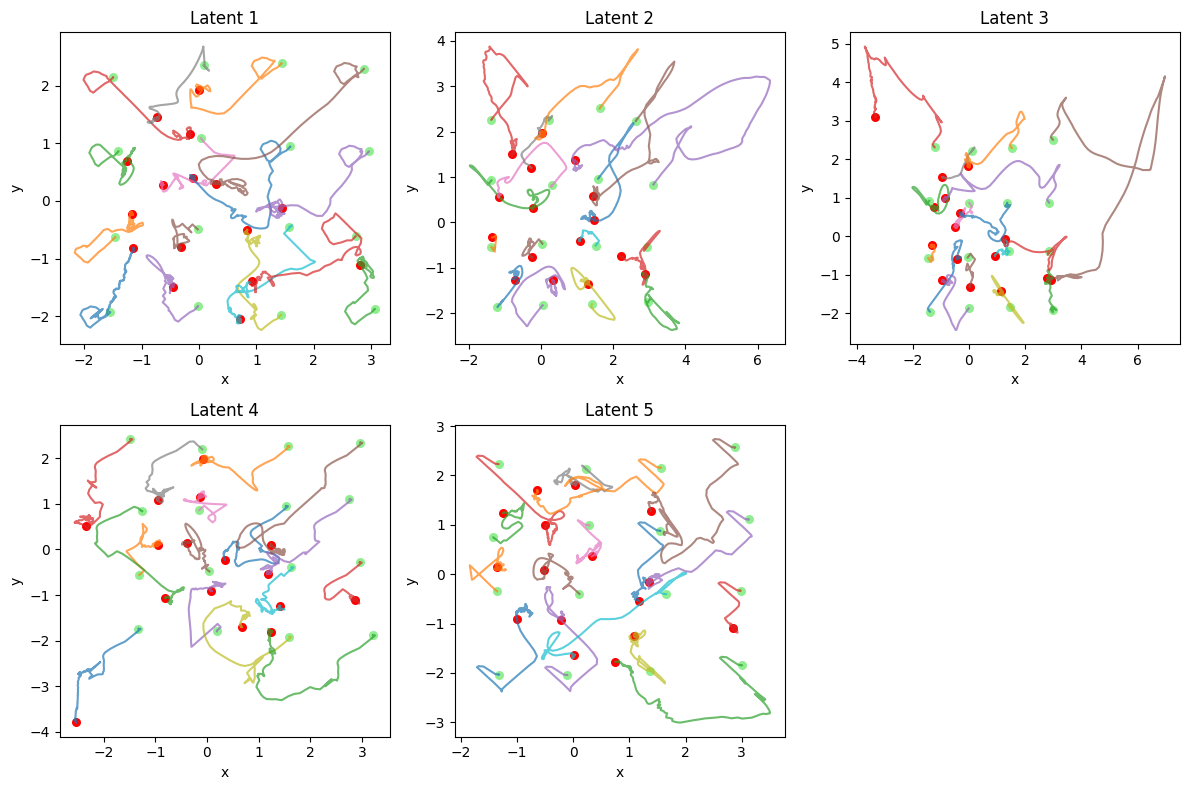

In [8]:
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), facecolor='white')

axes = axes.flatten()  # make indexing easy

steps, _, n_params, dim = points.shape

for j in range(num_latents):
    params = points[:, j, :, :].detach()
    ax = axes[j]
    
    for i in range(n_params):
        ax.scatter(params[-1, i, 0], params[-1, i, 1], color='red', s=30)   # end point
        ax.plot(params[:, i, 0], params[:, i, 1], alpha=0.7, lw=1.5)
        ax.scatter(params[0, i, 0], params[0, i, 1], color='lightgreen', s=30)   # start point
        
    
    ax.set_title(f"Latent {j+1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

# Hide unused subplots if num_latents < rows*cols
for j in range(num_latents, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("latents_working.png")
plt.show()

In [9]:
test_x = dataset.coords[test_dataset.indices]
test_y = dataset.Y[test_dataset.indices]

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    predictions = likelihood(model(test_x))
    mean = predictions.mean
    # lower, upper = predictions.confidence_region()
    
calculate_metrics(test_y, mean.clamp(min=0, max=1))

0.6900263509129273

In [10]:
model.covar_module.lengthscale

tensor([[[2.8355]],

        [[3.6793]],

        [[2.9207]],

        [[4.3959]],

        [[3.3461]]], grad_fn=<SoftplusBackward0>)

In [11]:
print(model.variational_strategy.lmc_coefficients.min())
print(model.variational_strategy.lmc_coefficients.max())
model.variational_strategy.lmc_coefficients.round(decimals=3)

tensor(-0.7758, grad_fn=<MinBackward1>)
tensor(1.4132, grad_fn=<MaxBackward1>)


tensor([[-0.1360, -0.0700, -0.0750,  ...,  0.0130, -0.0440, -0.0080],
        [ 0.0220, -0.1050, -0.0180,  ...,  0.0300,  0.1000, -0.0050],
        [-0.0820, -0.0260,  0.0750,  ..., -0.0090,  0.0730,  0.0950],
        [ 0.1670,  0.0750,  0.1290,  ..., -0.0010, -0.0210,  0.0740],
        [ 0.4700,  0.1180,  0.1470,  ...,  0.0050,  0.2590,  0.1140]],
       grad_fn=<RoundBackward1>)

# PYRO Spatial w. MultitaskGP

In [7]:

class SpatialModel(pyro.nn.PyroModule):
    def __init__(self, n_latents, n_species):
        self.n_latents = n_latents
        super().__init__()
        
        self.eta = MultitaskGPModel(num_latents=self.n_latents, num_tasks=n_species)
        
    def model(self, coords, batch_inverse, Y, training):
        pyro.module("model", self)
        
        eta_dist = self.eta.pyro_model(coords, name_prefix="eta_GP")

        with pyro.plate("eta_data_plate", size=coords.shape[0]):#, dim=-1):
            # Sample from latent function distribution
            eta_samples = pyro.sample("eta(coords)", eta_dist)

        eta_samples = eta_samples[batch_inverse]
        
        samples_plate = pyro.plate(name="samples_plate", size=Y.shape[0], dim=-2)
        species_plate = pyro.plate(name="species_plate", size=Y.shape[1], dim=-1)
        
        # scales = torch.ones_like(eta_samples) * 0.1
        
        with samples_plate, species_plate:
            pyro.sample("y", dist.Bernoulli(logits=eta_samples), obs=Y if training else None)
            # pyro.sample("y", dist.Normal(loc=eta_samples, scale=scales), obs=Y if training else None)
    
    def guide(self, coords, batch_inverse, Y, training):
        pyro.module("guide", self)
        eta_dist = self.eta.pyro_guide(coords, name_prefix="eta_GP")  # TODO: BREAKER
        # Use a plate here to mark conditional independencies
        with pyro.plate("eta_data_plate", size=coords.shape[0]):#, dim=-1):
            # Sample from latent function distribution
            eta_samples = pyro.sample("eta(coords)", eta_dist)
            
    def forward(self, coords, batch_inverse, Y, training):
        ...
        #self.model(coords, batch_inverse, Y, training)
    

In [8]:
pyro.clear_param_store()

model = SpatialModel(n_latents=num_latents, n_species=J)

optimizer = pyro.optim.Adam({"lr": 0.001})
elbo = pyro.infer.Trace_ELBO(num_particles=n_particles, vectorize_particles=True, retain_graph=True)
svi = pyro.infer.SVI(model.model, model.guide, optimizer, elbo)

In [9]:


points = [model.eta.variational_strategy.base_variational_strategy.inducing_points.clone().detach()]

losses = []

iterator = tqdm.notebook.tqdm(range(400))
for i in iterator:
    loss = 0
    for idx in train_dataloader:
        batch = train_dataset.dataset.get_batch_data(idx)
        
        coords = batch.get("coords")
        batch_inverse = batch.get("batch_inverse")
        Y = batch.get("Y")
        training = batch.get("training", True)
        
        loss += svi.step(coords, batch_inverse, Y, training)# / len(coords)

    iterator.set_postfix(loss=loss)
    
    points.append(model.eta.variational_strategy.base_variational_strategy.inducing_points.clone().detach())
    
    losses.append(loss)
    
points = torch.stack(points)

  0%|          | 0/400 [00:00<?, ?it/s]

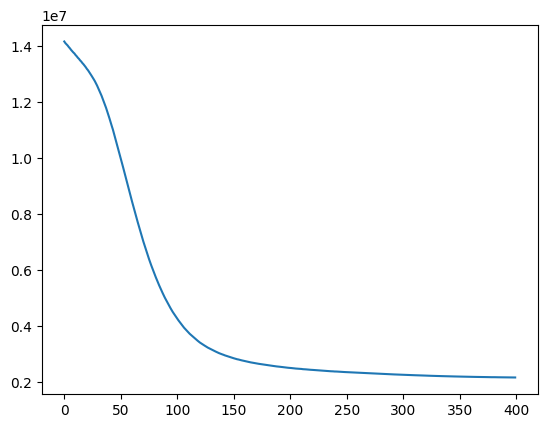

In [10]:
plt.plot(losses)

In [11]:
y_prob_list = []
y_test_list = []

for idx in train_dataloader:
    batch = dataset.get_batch_data(idx)
    batch["training"] = False
    batch["do_spatial"] = True
    
    coords = batch.get("coords")
    batch_inverse = batch.get("batch_inverse")
    Y = batch.get("Y")
    training = batch.get("training", True)

    predictive = pyro.infer.Predictive(model.model, guide=model.guide, num_samples=50)
    y_prob = predictive(coords, batch_inverse, Y, training)["y"].mean(dim=0)
    y_prob_list.append(y_prob)

    y_test_list.append(batch.get("Y"))

y_prob = torch.concat(y_prob_list)
test_Y = torch.concat(y_test_list)
del y_prob_list, y_test_list

metric_results = calculate_metrics(test_Y, y_prob)

print(metric_results)

0.5025439191146348


In [41]:
y = predictive(coords, batch_inverse, Y, training)["y"]

In [28]:
y.mean(dim=0)

tensor([[0.4400, 0.6400, 0.5800,  ..., 0.5600, 0.4600, 0.2800],
        [0.5200, 0.5400, 0.4200,  ..., 0.5800, 0.5000, 0.5200],
        [0.5600, 0.5000, 0.5200,  ..., 0.5200, 0.5600, 0.4400],
        ...,
        [0.5000, 0.5800, 0.6200,  ..., 0.5000, 0.4200, 0.5600],
        [0.3600, 0.3000, 0.4600,  ..., 0.4000, 0.5200, 0.5600],
        [0.4600, 0.2800, 0.4600,  ..., 0.4200, 0.3800, 0.6200]])

In [29]:
y_prob

tensor([[0.6000, 0.6600, 0.5600,  ..., 0.5800, 0.5200, 0.6200],
        [0.5400, 0.4600, 0.4200,  ..., 0.5400, 0.6200, 0.5600],
        [0.4400, 0.5000, 0.5400,  ..., 0.6000, 0.4400, 0.6000],
        ...,
        [0.5600, 0.7200, 0.5400,  ..., 0.6200, 0.5600, 0.4600],
        [0.4800, 0.4000, 0.3600,  ..., 0.4400, 0.4600, 0.4800],
        [0.5400, 0.2200, 0.3400,  ..., 0.4000, 0.4000, 0.4800]])

In [36]:
dataset.coords

tensor([[ 0.3923,  1.6980],
        [-0.5845, -1.2214],
        [ 0.9396, -0.0206],
        ...,
        [-0.4188, -0.6713],
        [-0.4409, -0.6580],
        [-0.4517, -0.6478]])

In [57]:
print(y_prob[:, y_prob.mean(dim=0).argmax()][:5])
print(test_Y[:, y_prob.mean(dim=0).argmax()][:5])

tensor([0.5800, 0.6000, 0.5200, 0.5600, 0.5400])
tensor([0., 0., 0., 1., 0.])


In [58]:
test_Y.mean(dim=0)

tensor([0.5846, 0.5610, 0.5161])

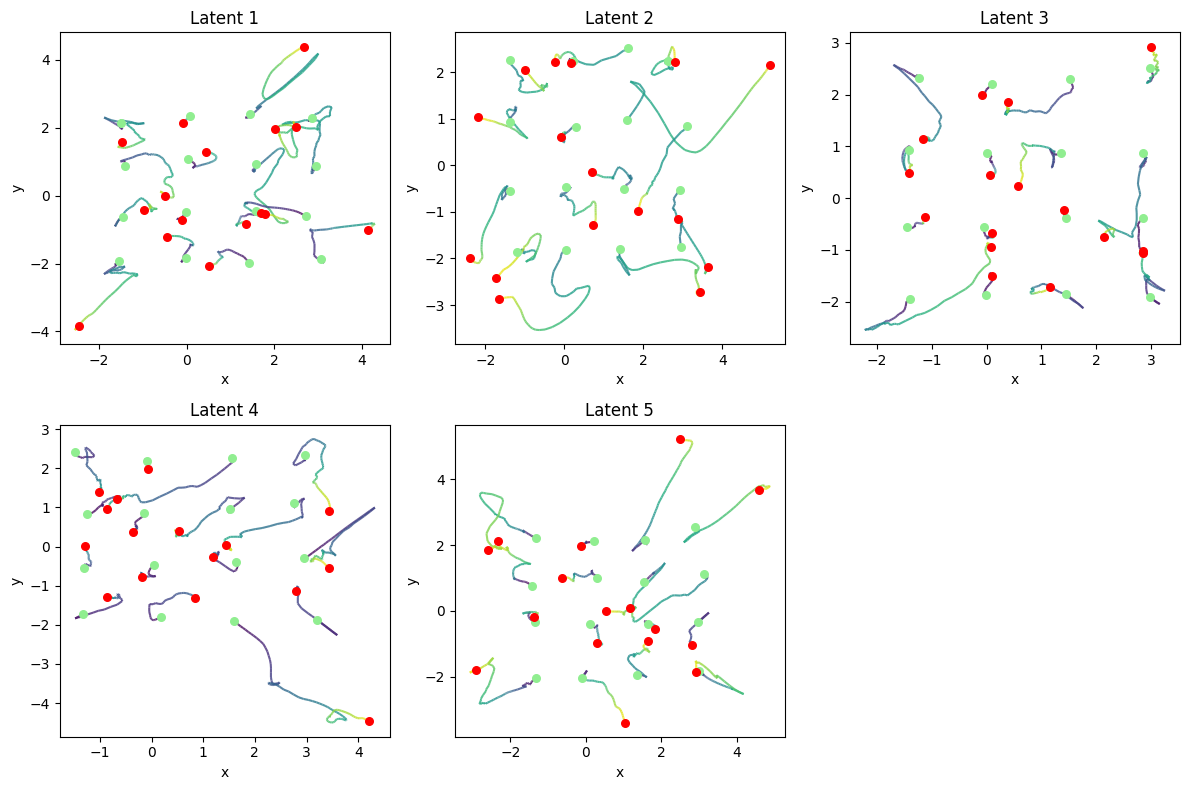

In [55]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows), facecolor='white')
axes = axes.flatten()

steps, _, n_params, dim = points.shape

for j in range(num_latents):
    params = points[:, j, :, :].detach()
    ax = axes[j]

    for i in range(n_params):
        # Build line segments for each trajectory
        x = params[:, i, 0]
        y = params[:, i, 1]
        points_ = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points_[:-1], points_[1:]], axis=1)
        
        # Define color gradient along steps
        colors = plt.cm.viridis(np.linspace(0, 1, len(segments)))
        
        # Create the colored line
        lc = LineCollection(segments, colors=colors, linewidth=1.5, alpha=0.8)
        ax.add_collection(lc)
        
        # Mark start and end points
        ax.scatter(x[0], y[0], color='lightgreen', s=30, zorder=3)
        ax.scatter(x[-1], y[-1], color='red', s=30, zorder=3)

    ax.set_title(f"Latent {j+1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.autoscale()  # adjust view to data

# Hide unused subplots
for j in range(num_latents, rows * cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("latents_pyro.png")
plt.show()


In [44]:
model.eta.variational_strategy.lmc_coefficients

Parameter containing:
tensor([[ 0.0096,  0.1272, -0.0161,  ...,  0.1798,  0.0225,  0.0121],
        [-0.0097, -0.0228,  0.1022,  ..., -0.9205, -0.0214, -0.0123],
        [-0.1643, -0.5431, -0.5393,  ..., -0.8265,  0.2319, -0.1685],
        [ 0.3334,  0.4148,  0.3866,  ..., -0.1082,  0.8673,  0.6586],
        [ 0.1789,  0.3116,  0.0732,  ...,  1.0488,  0.5145,  0.4087]],
       requires_grad=True)

In [45]:
model.eta.covar_module.lengthscale

tensor([[[6.6408e-03]],

        [[1.5983e-03]],

        [[9.9788e-01]],

        [[1.1099e+00]],

        [[1.6314e+00]]], grad_fn=<SoftplusBackward0>)

# Don't go futher :)

In [6]:
class GP_low(gpytorch.models.ApproximateGP):
    def __init__(self, num_latents, num_tasks):
        # Let's use a different set of inducing points for each latent function
        # inducing_points = torch.rand(num_latents, 16, n_S)
        a = torch.linspace(coords[:, 0].min(), coords[:, 0].max(), 4)
        b = torch.linspace(coords[:, 1].min(), coords[:, 1].max(), 4)
        A, B = torch.meshgrid(a, b, indexing="ij")
        inducing_points = torch.stack([A.flatten(), B.flatten()], dim=1).repeat(5, 1, 1)

        # We have to mark the CholeskyVariationalDistribution as batch
        # so that we learn a variational distribution for each task
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([num_latents])
        )

        # We have to wrap the VariationalStrategy in a LMCVariationalStrategy
        # so that the output will be a MultitaskMultivariateNormal rather than a batch output
        variational_strategy = gpytorch.variational.LMCVariationalStrategy(
            gpytorch.variational.VariationalStrategy(
                self, inducing_points, variational_distribution, learn_inducing_locations=True
            ),
            num_tasks=num_tasks,
            num_latents=num_latents,
        )

        super().__init__(variational_strategy)

        # The mean and covariance modules should be marked as batch
        # so we learn a different set of hyperparameters
        self.mean_module = gpytorch.means.ConstantMean(batch_shape=torch.Size([num_latents]))
        self.covar_module = gpytorch.kernels.RBFKernel(batch_shape=torch.Size([num_latents]))
        
        # self.covar_module.lengthscale = torch.ones(num_latents, 1, 1, dtype=torch.float32)
            

    def forward(self, x):
        # The forward function should be written as if we were dealing with each output
        # dimension in batch
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
    def model(self, coords, batch_inverse, Y, training):
        pyro.module("model", self)
        
        eta_dist = self.pyro_model(coords, name_prefix="eta_GP")

        with pyro.plate("eta_data_plate", size=coords.shape[0], dim=-1):
            # Sample from latent function distribution
            eta_samples = pyro.sample("eta(coords)", eta_dist)
            # eta_samples = eta_samples if eta_samples.shape == torch.Size([coords.shape[0], J]) else eta_samples.mean(
            #     dim=0).reshape(coords.shape[0], J)

            eta_samples = eta_samples[batch_inverse]
        
        samples_plate = pyro.plate(name="samples_plate", size=Y.shape[0], dim=-2)
        species_plate = pyro.plate(name="species_plate", size=Y.shape[1], dim=-1)
        
        with species_plate:
            bias = pyro.sample("b", dist.Normal(loc=torch.zeros(J), scale=torch.ones(J)))

        z = eta_samples + bias
        
        # scales = torch.ones_like(eta_samples) * 0.1
        
        with samples_plate, species_plate:
            pyro.sample("y", dist.Bernoulli(logits=z), obs=Y if training else None)
            # pyro.sample("y", dist.Normal(loc=eta_samples, scale=scales), obs=Y if training else None)
    
    def guide(self, coords, batch_inverse, Y, training):
        eta_dist = self.pyro_guide(coords, name_prefix="eta_GP")
        # Use a plate here to mark conditional independencies
        with pyro.plate("eta_data_plate", size=coords.shape[0], dim=-1):
            # Sample from latent function distribution
            eta_samples = pyro.sample("eta(coords)", eta_dist)
            
        bias_loc = pyro.param("bias_loc", torch.zeros(J))
        bias_scale = pyro.param("bias_scale", torch.ones(J), constraint=dist.constraints.positive)

        species_plate = pyro.plate(name="species_plate", size=Y.shape[1], dim=-1)
        with species_plate:
            bias = pyro.sample("b", dist.Normal(loc=bias_loc, scale=bias_scale))

In [7]:
model = GP_low(5, J)

def train():
    pyro.clear_param_store()
    
    optimizer = pyro.optim.AdamW({"lr": 0.01})
    elbo = pyro.infer.Trace_ELBO(num_particles=1, vectorize_particles=True, retain_graph=True)
    svi = pyro.infer.SVI(model.model, model.guide, optimizer, elbo)

    model.train()
    iterator = tqdm.notebook.tqdm(range(200))
    for i in iterator:
        loss = 0
        for idx in train_dataloader:
            model.zero_grad()
            batch = train_dataset.dataset.get_batch_data(idx)
            
            coords = batch.get("coords")
            batch_inverse = batch.get("batch_inverse")
            Y = batch.get("Y")
            training = batch.get("training", True)
            
            loss += svi.step(coords, batch_inverse, Y, training)
    
        iterator.set_postfix(loss=loss)
        
train()

  0%|          | 0/200 [00:00<?, ?it/s]

In [8]:
y_prob_list = []
y_test_list = []

test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

for idx in test_dataloader:
    batch = dataset.get_batch_data(idx)
    batch["training"] = False
    batch["do_spatial"] = True
    
    coords = batch.get("coords")
    batch_inverse = batch.get("batch_inverse")
    Y = batch.get("Y")
    training = batch.get("training", True)

    predictive = pyro.infer.Predictive(model.model, guide=model.guide, num_samples=50)
    y_prob = predictive(coords, batch_inverse, Y, training)["y"].mean(dim=0)
    y_prob_list.append(y_prob)

    y_test_list.append(batch.get("Y"))

y_prob = torch.concat(y_prob_list)
test_Y = torch.concat(y_test_list)
del y_prob_list, y_test_list

metric_results = calculate_metrics(test_Y, y_prob)

print(metric_results)

0.5016040184434414


# Mini EcoGP

In [5]:
from EcoGP.MultitaskVariationalStrategy import MultitaskVariationalStrategy

class HaversineRBFKernel(gpytorch.kernels.Kernel):
    """A GPyTorch kernel that computes the Haversine distance and applies an RBF transformation."""

    has_lengthscale = True  # Allows GPyTorch to learn the lengthscale

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def forward(self, x1, x2, diag=False, **params):
        """Compute the kernel matrix using Haversine distance with RBF transformation."""
        if diag:
            return torch.ones(num_latents, x1.shape[-2])
        # Convert degrees to radians
        RADIUS = 6373  # Approximate radius of Earth in km

        # Convert degrees to radians
        lon1, lat1, lon2, lat2 = map(torch.deg2rad, (x1[:, :, 0], x1[:, :, 1], x2[:, :, 0], x2[:, :, 1]))

        # Compute differences
        dlon = lon2.unsqueeze(1) - lon1.unsqueeze(2)
        dlat = lat2.unsqueeze(1) - lat1.unsqueeze(2)

        # Haversine formula
        a = torch.sin(dlat / 2) ** 2 + torch.cos(lat1.unsqueeze(2)) * torch.cos(lat2.unsqueeze(1)) * torch.sin(
            dlon / 2) ** 2
        c = 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))

        haversine_dist = RADIUS * c

        # Apply the RBF kernel
        rbf_kernel = torch.exp(-0.5 * (haversine_dist / self.lengthscale) ** 2)

        return rbf_kernel

class SpatialGP(gpytorch.models.ApproximateGP):
    def __init__(self, n_latents):
        self.n_latents = n_latents
        a = torch.linspace(coords[:, 0].min(), coords[:, 0].max(), 4)
        b = torch.linspace(coords[:, 1].min(), coords[:, 1].max(), 4)
        A, B = torch.meshgrid(a, b, indexing="ij")
        inducing_points = torch.stack([A.flatten(), B.flatten()], dim=1).repeat(n_latents, 1, 1)

        # We have to mark the CholeskyVariationalDistribution as batch
        # so that we learn a variational distribution for each task
        variational_distribution = gpytorch.variational.CholeskyVariationalDistribution(
            inducing_points.size(-2), batch_shape=torch.Size([n_latents])
        )

        variational_strategy = MultitaskVariationalStrategy(  # CustomVariationalStrategy
            base_variational_strategy=gpytorch.variational.VariationalStrategy(
                self, inducing_points, variational_distribution, learn_inducing_locations=True
            ),
        )

        super().__init__(variational_strategy)

        # The mean and covariance modules should be marked as batch, so we learn a different set of hyperparameters
        self.mean_module = gpytorch.means.ZeroMean(batch_shape=torch.Size([n_latents]))
        self.covar_module = gpytorch.kernels.RBFKernel(
            # HaversineRBFKernel(  # gpytorch.kernels.RBFKernel(#HaversineRBFKernel(  # CustomSpatialKernel(#
            # lengthscale_prior=gpytorch.priors.GammaPrior(rate=1, concentration=5),
            lengthscale_prior=gpytorch.priors.NormalPrior(2, 1),
            batch_shape=torch.Size([n_latents]),
            # ard_num_dims=n_S
        )
        self.covar_module.lengthscale = torch.rand(n_latents, 1, 1) * 2
        # self.covar_module.base_kernel.lengthscale = torch.ones(n_latents, 1, 1, requires_grad=False) * 3
        # self.covar_module.outputscale = torch.rand(n_latents, 1, 1)

    def forward(self, x):
        # The forward function should be written as if we were dealing with each output
        # dimension in batch
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [13]:
class MiniEcoGP(pyro.nn.PyroModule):
    def __init__(self,
                 n_latents_spatial=None,
                 likelihood=None):
        super().__init__()

        self.likelihood = likelihood

        self.n_latents_spatial = n_latents_spatial
        self.g = SpatialGP(n_latents=n_latents_spatial)

    def model(self, batch):
        pyro.module("model", self)

        n_samples = batch.get("n_samples_batch")
        n_species = batch.get("n_species")

        samples_plate = pyro.plate(name="samples_plate", size=n_samples, dim=-2)
        species_plate = pyro.plate(name="species_plate", size=n_species, dim=-1)

        g_dist = self.g.pyro_model(batch.get("coords"), name_prefix="g_GP")

        with pyro.plate("M_plate", dim=-1):
            # Sample from latent function distribution
            g_samples = pyro.sample(".g(coords)", g_dist)

        g_samples = g_samples if g_samples.shape == torch.Size(
            [batch["n_locs_batch"], self.n_latents_spatial]) else g_samples.mean(dim=0).reshape(
            batch["n_locs_batch"], self.n_latents_spatial)
        g_samples = g_samples[batch["batch_inverse"]]

        v = pyro.param("v", torch.randn(self.n_latents_spatial, n_species))
        # v_loc = torch.zeros(self.n_latents_spatial, n_species)
        # v_scale = torch.ones(self.n_latents_spatial, n_species)
        # with species_plate, pyro.plate("spatial_latents_plate_v", self.n_latents_spatial, dim=-2):
        #     v = pyro.sample("v", dist.Normal(loc=v_loc, scale=v_scale))

        with species_plate:
            bias = pyro.sample("b", dist.Normal(loc=torch.zeros(n_species), scale=torch.ones(n_species)))

        z = g_samples @ v + bias

        self.likelihood(z, batch, samples_plate, species_plate)

    def guide(self, batch):
        n_species = batch.get("n_species")
        species_plate = pyro.plate(name="species_plate", size=n_species, dim=-1)

        g_dist = self.g.pyro_guide(batch.get("coords"), name_prefix="g_GP")  # TODO: BREAKER
        # Use a plate here to mark conditional independencies
        with pyro.plate("M_plate", dim=-1):
            # Sample from latent function distribution
            g_samples = pyro.sample(".g(coords)", g_dist)

        # v_loc = pyro.param("v_loc", torch.zeros(self.n_latents_spatial, n_species))
        # v_scale = pyro.param(
        #     "v_scale",
        #     0.1 * torch.ones(self.n_latents_spatial, n_species),
        #     constraint=dist.constraints.positive
        # )
        # 
        # with species_plate, pyro.plate("spatial_latents_plate_v", self.n_latents_spatial, dim=-2):
        #     v = pyro.sample("v", dist.Normal(loc=v_loc, scale=v_scale))

        bias_loc = pyro.param("bias_loc", torch.zeros(n_species))
        bias_scale = pyro.param("bias_scale", torch.ones(n_species), constraint=dist.constraints.positive)

        with species_plate:
            bias = pyro.sample("b", dist.Normal(loc=bias_loc, scale=bias_scale))

    def forward(self, x):
        ...

In [14]:
pyro.clear_param_store()

model = MiniEcoGP(num_latents, likelihood)

optimizer = pyro.optim.Adam({"lr": 0.01})
elbo = pyro.infer.Trace_ELBO(num_particles=1, vectorize_particles=True, retain_graph=True)
svi = pyro.infer.SVI(model.model, model.guide, optimizer, elbo)

model.train()
iterator = tqdm.notebook.tqdm(range(200))
for i in iterator:
    loss = 0
    for idx in train_dataloader:
        model.zero_grad()
        batch = train_dataset.dataset.get_batch_data(idx)
        
        loss += svi.step(batch)

    iterator.set_postfix(loss=loss, lengthscale=str([round(i.item(), 3) for i in model.g.covar_module.lengthscale.squeeze()]))

  0%|          | 0/200 [00:00<?, ?it/s]

In [15]:
y_prob_list = []
y_test_list = []

test_dataloader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

for idx in test_dataloader:
    batch = dataset.get_batch_data(idx)
    batch["training"] = False
    # batch["do_spatial"] = True

    predictive = pyro.infer.Predictive(model.model, guide=model.guide, num_samples=50)
    y_prob = predictive(batch)["y"].mean(dim=0)
    y_prob_list.append(y_prob)

    y_test_list.append(batch.get("Y"))

y_prob = torch.concat(y_prob_list)
test_Y = torch.concat(y_test_list)
del y_prob_list, y_test_list

metric_results = calculate_metrics(test_Y, y_prob)

print(metric_results)

0.5162630079588194


In [16]:
y_prob

tensor([[0.2000, 0.0400, 0.0800,  ..., 0.0200, 0.1000, 0.0200],
        [0.1600, 0.0200, 0.0600,  ..., 0.0200, 0.0200, 0.0400],
        [0.1200, 0.0400, 0.0600,  ..., 0.0000, 0.0600, 0.0200],
        ...,
        [0.1800, 0.0400, 0.0600,  ..., 0.0000, 0.0600, 0.0600],
        [0.1200, 0.0000, 0.0200,  ..., 0.0000, 0.1000, 0.0600],
        [0.1600, 0.0200, 0.0400,  ..., 0.0000, 0.0800, 0.0600]])